Modules
==============================

In [1]:
using FFTW
#FFTW.set_num_threads(4)

using LinearAlgebra
#BLAS.set_num_threads(4)

using SparseArrays

using CMBrings
using CMBrings: pcg, brickplot, diskplot
using CMBrings: AzBlock, check_factorization, az_sim
using CMBrings: Nabla!
using CMBrings.FieldLensing: ArrayLense
using XFields
using Spectra

using FFTransforms: 𝕀, 𝕎, r𝕎, ⊗, unitary_scale, ordinary_scale, fullfreq
import CMBsphere
const ST = CMBsphere.SphereTransforms

using DelimitedFiles
using Statistics
using Dierckx: Spline1D
using LBblocks: @sblock
using PyPlot
using NLopt
using BenchmarkTools


hide_plots = false

false

Mask and CMBring observation region
==============================

In [2]:
QP_boundry_clearance = 1e-5
Tp=Float32

Float32

In [3]:
ma, maᶜ, Ωℝ64, θℝ64, φℝ64, s0, s0_clip = @sblock let QP_boundry_clearance, Tp

    # ------------------
    # ma𝕊 = readdlm("FastTransform_mask_nθ3072_nφ4095.csv", ',', Bool)
    # nθ𝕊, nφ𝕊 = size(ma𝕊)
    # s0_clip = (78*nθ𝕊÷100):(87*nθ𝕊÷100) # default
    # # s0_clip = (75*nθ𝕊÷100):(85*nθ𝕊÷100)
    # # s0_clip = (72*nθ𝕊÷100):(87*nθ𝕊÷100)
    # # s0_clip = (69*nθ𝕊÷100):(90*nθ𝕊÷100)
    # ------------------
    # # ma𝕊      = readdlm("FastTransform_mask_spole_nθ3072_nφ4095.csv", ',', Bool)
    # ma𝕊      = readdlm("FastTransform_mask_spole_nθ3072_nφ3071.csv", ',', Bool)
    # nθ𝕊, nφ𝕊 = size(ma𝕊)
    # s0_clip  = (84*nθ𝕊÷100):(98*nθ𝕊÷100) # default
    # # s0_clip  = (82*nθ𝕊÷100):(97*nθ𝕊÷100)
    # # s0_clip  = (87*nθ𝕊÷100):(985*nθ𝕊÷1000)
    # # s0_clip  = (82*nθ𝕊÷100):(99*nθ𝕊÷100)
    # ------------------
    # ma𝕊      = readdlm("FastTransform_mask_nearpole_nθ3072_nφ3071.csv", ',', Bool)
    # nθ𝕊, nφ𝕊 = size(ma𝕊)
    # s0_clip  = (84*nθ𝕊÷100):(97*nθ𝕊÷100)
    # ---------------------
    ma𝕊  = readdlm("FastTransform_mask_mid2pole_nθ2560_nφ3071.csv", ',', Bool)
    # ma𝕊  = readdlm("FastTransform_mask_mid2pole_nθ2560_nφ4095.csv", ',', Bool)
    nθ𝕊, nφ𝕊 = size(ma𝕊)
    ##s0_clip  = (79*nθ𝕊÷100):(96*nθ𝕊÷100)
    s0_clip  = (81*nθ𝕊÷100):(92*nθ𝕊÷100)


    s0 = ST.𝕊(Float64, nθ𝕊, nφ𝕊, 0)
    Ωℝ = ST.Ωpix(s0)[s0_clip]
    θℝ, φℝ = ST.pix(s0) |> x->(x[1][s0_clip], x[2])

    𝕨 = r𝕎(nθ𝕊, π) ⊗ r𝕎(nφ𝕊, 2π) |> x-> ordinary_scale(x)*x
    # beamfwhm1 = (arcmin=100.0; deg2rad(arcmin/60))
    # beamfwhm2 = (arcmin=200.0; deg2rad(arcmin/60))
    beamfwhm1 = (arcmin=200.0; deg2rad(arcmin/60))
    beamfwhm2 = (arcmin=300.0; deg2rad(arcmin/60))
    σ²1 = beamfwhm1^2 / 8 / log(2)
    σ²2 = beamfwhm2^2 / 8 / log(2)
    k   = fullfreq(𝕨)
    bk  = @. exp( - σ²1 * k[1]^2 / 2) * exp( - σ²2 * k[2]^2 / 2)
    Bt  = DiagOp(Xfourier(𝕨, bk))

    ps_qs = ma𝕊 .- .!(ma𝕊 .> 0)
    Bps_qs =  (Bt * Xmap(𝕨, ps_qs))[:]
    psBool = @. Bps_qs > 0

    Aps_qs   = @. abs(Bps_qs)
    Aps_qs .+= QP_boundry_clearance
    Aps_qs ./= maximum(Aps_qs)
    ps = Aps_qs .* psBool
    qs = Aps_qs .* .!psBool

    @assert all(abs.(qs.*ps) .== 0)
    @assert all(abs.(qs) .+ abs.(ps) .> 0)

    Ps  = DiagOp(Xmap(s0, ps))
    Qs  = DiagOp(Xmap(s0, qs))


    Tp.(Ps[:][s0_clip,:]), Tp.(Qs[:][s0_clip,:]), Ωℝ, θℝ, φℝ, s0, s0_clip
end;

Ωℝ, θℝ, φℝ = Tp.(Ωℝ64), Tp.(θℝ64), Tp.(φℝ64)

(Float32[1.4153466f-6, 1.4128005f-6, 1.4102523f-6, 1.407702f-6, 1.4051495f-6, 1.402595f-6, 1.4000384f-6, 1.3974795f-6, 1.3949187f-6, 1.3923558f-6  …  6.5479855f-7, 6.518235f-7, 6.4884745f-7, 6.4587044f-7, 6.428924f-7, 6.399135f-7, 6.369335f-7, 6.3395265f-7, 6.309708f-7, 6.27988f-7], Float32[2.5433402, 2.5445673, 2.5457945, 2.5470216, 2.5482488, 2.5494761, 2.5507033, 2.5519304, 2.5531576, 2.5543847  …  2.8783615, 2.8795888, 2.880816, 2.8820431, 2.8832703, 2.8844974, 2.8857245, 2.886952, 2.888179, 2.8894062], Float32[0.0, 0.0020459737, 0.0040919473, 0.006137921, 0.008183895, 0.010229869, 0.012275842, 0.014321816, 0.01636779, 0.018413763  …  6.2627254, 6.2647715, 6.2668176, 6.2688637, 6.2709093, 6.2729554, 6.2750015, 6.277047, 6.2790933, 6.2811394])

Azimuthal ring mask

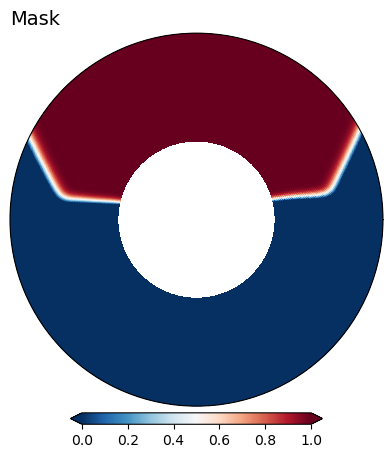

(Figure(PyObject <Figure size 450x500 with 2 Axes>), PyCall.PyObject[PyObject <matplotlib.axes._subplots.PolarAxesSubplot object at 0x7fd23e36ff50>])

In [4]:
@sblock let ma, φℝ, θℝ, hide_plots
    hide_plots && return
    imgs = Dict(1=>ma)
    txt  = Dict(1=>"Mask")
    ctxt = Dict(1=>"w")
    # brickplot(imgs; txt=txt, ctxt=ctxt, fφ=1)
    diskplot(imgs, φℝ', π.-θℝ; txt=txt, nrows=1, fontsize=14)
end

Plot √Ωpix over ring θℝ's

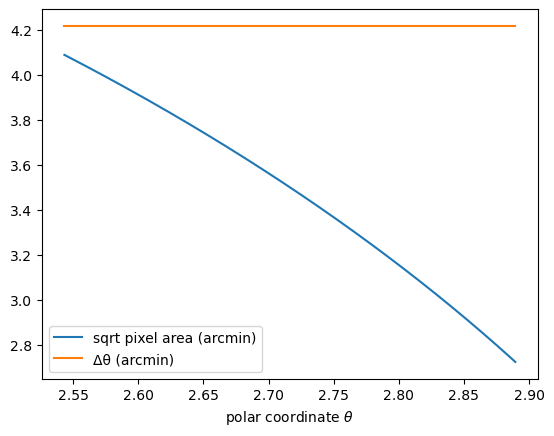

In [5]:
@sblock let θℝ, φℝ, Ωℝ, hide_plots
    hide_plots && return
    fig,ax = subplots(1)
    ax.plot(θℝ, rad2deg.(sqrt.(Ωℝ)).*60, label="sqrt pixel area (arcmin)")
    ax.plot(θℝ, zero(θℝ) .+ rad2deg.(θℝ[2] - θℝ[1]).*60, label="Δθ (arcmin)")
    # ax.plot(θℝ, zero(θℝ) .+ rad2deg.(φℝ[2] - φℝ[1]).*60, label="Δφ (arcmin)")
    ax.set_xlabel(L"polar coordinate $\theta$")
    ax.legend()
end;

Set ring transforms
==============================

In [6]:
tmU, tmW = @sblock let nθ=length(θℝ), nφ=length(φℝ)
    tmW32 = 𝕀(nθ) ⊗ 𝕎(Float32, nφ, 2π)
    tmW64 = 𝕀(nθ) ⊗ 𝕎(Float64, nφ, 2π)
    # tmU  = unitary_scale(tmW32)*tmW32
    tmU  = unitary_scale(tmW64)*tmW64
    tmU, tmW64
end

(𝕎{Float64,2,Float64,Float64}((283, 3071), (false, true), 0.01804513318462704, (283.0, 6.283185307179586)), 𝕎{Float64,2,Bool,Float64}((283, 3071), (false, true), true, (283.0, 6.283185307179586)))

masking
==========================

In [7]:
Pr, Qr = @sblock let tmU, ma, maᶜ
    Pr = Xmap(tmU, ma)
    Qr = Xmap(tmU, maᶜ)
    DiagOp(Pr), DiagOp(Qr)
end;

ϕϕ, TT covariance
================================

In [8]:
rcϕ = 1e5

ttl, ϕϕl = @sblock let rcϕ, lmax = 8000
    l = 0:lmax
    cld = Spectra.camb_cls(lmax=lmax)
    ctlvec = cld[:unlen_scalar] |> x->(x[:Ctt] ./ x[:factor_on_cl_cmb])
    ctlvec[2] = 1e-1 * ctlvec[3]
    ctlvec[1] = 1e-2 * ctlvec[3]
    cϕlvec = cld[:phi] |> x->(x[:Cϕϕ] ./ x[:factor_on_cl_phi])
    # cϕlvec = Spectra.cϕl_approx.(l)
    cϕlvec[2] =  .5 * cϕlvec[3]
    cϕlvec[1] = .25 * cϕlvec[3]

    ctlvec, rcϕ^2 .* cϕlvec
end;

Note: ϕ is now the "new" rescaled version which need to be adjusted when
converted to a displacement (and the transpose of that ...)

Note: to get this positive definite it appears we need
twice precision for θℝ and φℝ

In [9]:
Φaz = @sblock let Tp, tmW, ϕϕl, θℝ=θℝ64, φℝ=φℝ64
    ##θgrid = range(0, π^(1/2), length=50_000).^2
    dmax = 1.2maximum(CMBrings.geoθ1θ2Δφcol(θℝ[1], θℝ[1], φℝ .- φℝ[1]))
    θgrid = range(0, dmax^(1/2), length=50_000).^2
    covf  = Spline1D(
        θgrid,
        Spectra.spec2spherecov(ϕϕl, θgrid),
        k=3
    )
    covf_θ1θ2Δφℝ = (θ1,θ2,Δφℝ) -> covf(CMBrings.geoθ1θ2Δφcol(θ1, θ2, Δφℝ))

    Φaz = AzBlock(covf_θ1θ2Δφℝ, θℝ, φℝ, tmW) do A, k
        ##real.(A) + 1e-8*I(length(θℝ))
        A = Symmetric(real.(A),:L)
        C = cholesky(A, Val(false)) #, check=false)
        # Cholesky(Tp.(C.factors), C.uplo, C.info)
        C
    end

    Φaz
end;

In [10]:
Σaz = @sblock let Tp, tmW, ttl, θℝ=θℝ64, φℝ=φℝ64
	##θgrid = range(0, π^(1/2), length=50_000).^2
    dmax = 1.2maximum(CMBrings.geoθ1θ2Δφcol(θℝ[1], θℝ[1], φℝ .- φℝ[1]))
    θgrid = range(0, dmax^(1/2), length=50_000).^2
    covf  = Spline1D(
        θgrid,
        Spectra.spec2spherecov(ttl, θgrid),
        k=3
    )
    covf_θ1θ2Δφℝ = (θ1,θ2,Δφℝ) -> covf(CMBrings.geoθ1θ2Δφcol(θ1, θ2, Δφℝ))

    Σaz = AzBlock(covf_θ1θ2Δφℝ, θℝ, φℝ, tmW) do A, k
        ##real.(A) + 1e-8*I(length(θℝ))
        A = Symmetric(real.(A),:L)
        # A = Symmetric(real.(A) + 1e-8*I(length(θℝ)),:L)
        C = cholesky(A, Val(false)) #, check=false)
        Cholesky(Tp.(C.factors), C.uplo, C.info)
    end

    Σaz
end;

Beam/Transfer function
================================

In [11]:
beamfwhm    = 3.5 |> arcmin -> deg2rad(arcmin/60)
azmuth_transfer_k = k -> 1
# azmuth_transfer_k = k -> inv(1 + (k/200)^2)
# azmuth_transfer_k = k -> inv(1 + (k/75)^2)

#20 (generic function with 1 method)

In [12]:
bl = @sblock let beamfwhm, lmax = 8000
    l = 0:lmax
    σ² = beamfwhm^2 / 8 / log(2)
    bl = @. exp( - σ²*l*(l+1) / 2)
    return bl
end;

In [13]:
Baz = @sblock let Tp, tmW, bl, θℝ=θℝ64, φℝ=φℝ64, Ωℝ=Ωℝ64, azmuth_transfer_k
    ##θgrid = range(0, π^(1/2), length=50_000).^2
    dmax = 1.2maximum(CMBrings.geoθ1θ2Δφcol(θℝ[1], θℝ[1], φℝ .- φℝ[1]))
    θgrid = range(0, dmax^(1/2), length=50_000).^2

    covf  = Spline1D(
        θgrid,
        Spectra.spec2spherecov(bl, θgrid),
        k=3
    )

    covf_θ1θ2Δφℝ = (θ1,θ2,Δφℝ) -> covf(CMBrings.geoθ1θ2Δφcol(θ1, θ2, Δφℝ))

    Baz  = AzBlock(covf_θ1θ2Δφℝ, θℝ, φℝ, tmW) do Σ, k
        Tp.(azmuth_transfer_k(k) * real.(Σ) * Diagonal(Ωℝ))
    end

    Baz
end;

Noise with weights weight and mask/projection
==============================

In [14]:
μK′n      = 3.0 # 10.0
ellknee   = 0   # 150
alphaknee = 3
# weight_θ  = θ -> 1 + 0.15 * sin(300 * θ) # θ -> 1
weight_θ  = θ -> 1
# weight_θ  = θ -> 1 + 1 ./ sin(θ).^2 # θ -> 1

#26 (generic function with 1 method)

In [15]:
nnl, snl = @sblock let μK′n, ellknee, alphaknee, lmax = 8000
    l = 0:lmax
    whitenoisel    = fill(μK′n^2 * (π/60/180)^2, size(l))
    smoothnoisel   = @. μK′n^2 * (π/60/180)^2 * Spectra.knee(l; ell=ellknee, alpha=alphaknee)
    smoothnoisel .-= μK′n^2 * (π/60/180)^2
    smoothnoisel[smoothnoisel .< 0] .= 0
    noisel = smoothnoisel .+ whitenoisel
    return noisel, smoothnoisel
end;

In [16]:
Naz = @sblock let Tp, tmW, μK′n, snl, weight_θ, θℝ=θℝ64, φℝ=φℝ64, Δθ = θℝ64[2]-θℝ64[1], Δφ = φℝ64[2]-φℝ64[1]
    # θgrid = range(0, π^(1/2), length=50_000).^2
    dmax = 1.2maximum(CMBrings.geoθ1θ2Δφcol(θℝ[1], θℝ[1], φℝ .- φℝ[1]))
    θgrid = range(0, dmax^(1/2), length=50_000).^2
    covf  = Spline1D(
        θgrid,
        Spectra.spec2spherecov(snl, θgrid),
        k=3
    )

    covf_θ1θ2Δφℝ = function (θ1, θ2, Δφℝ)
        rtn   = covf(CMBrings.geoθ1θ2Δφcol(θ1, θ2, Δφℝ))
        if θ1 == θ2
            cc = μK′n^2 * (π/60/180)^2
            pa = ST.Ωpix(θ1, Δθ, Δφ) # sin(θ1) * Δθ * Δφ
            rtn[Δφℝ .== 0] .+= cc / pa # <- since we are using ST grid
        end
        rtn
    end

    Naz = AzBlock(covf_θ1θ2Δφℝ, θℝ, φℝ, tmW) do N, k
        WD = Diagonal(weight_θ.(θℝ))
        A = Symmetric(WD*(real.(N))*WD',:L)
        C = cholesky(A, Val(false)) #, check=false)
        Cholesky(Tp.(C.factors), C.uplo, C.info)
    end

    Naz
end;

negative Hessian  for ϕ gradient -> newton update
==============================

In [17]:
n2s_ratio = 0.2

ϕnnl = @sblock let ϕϕl, n2s_ratio, lmax = 8000
    l      = 0:lmax
    lpeak  = 40
    ϕnnl    = @. n2s_ratio * lpeak^4 * ϕϕl[lpeak+1] / (l + 1)^4
    # ϕnnl   = @. 1 / (1 / nnl + 1 / ϕϕl)
    ϕnnl
end;

# figure()
# (0:8000).^4 .* ϕϕl |> loglog
# (0:8000).^4 .* ϕnnl |> loglog
# (0:8000).^4 .* inv.(inv.(ϕnnl) .+ inv.(ϕϕl)) |> loglog
# (0:8000).^4 .* ϕnnl .* inv.(ϕnnl .+ ϕϕl) |> loglog

In [18]:
NΦNaz = @sblock let Tp, tmW, Φaz, ϕnnl, θℝ=θℝ64, φℝ=φℝ64

	##θgrid = range(0, π^(1/2), length=50_000).^2
    dmax = 1.2maximum(CMBrings.geoθ1θ2Δφcol(θℝ[1], θℝ[1], φℝ .- φℝ[1]))
    θgrid = range(0, dmax^(1/2), length=50_000).^2

    covϕnn  = Spline1D(
        θgrid,
        Spectra.spec2spherecov(ϕnnl, θgrid),
        k=3
    )


    covϕnn_θ1θ2Δφℝ = (θ1,θ2,Δφℝ) -> covϕnn(CMBrings.geoθ1θ2Δφcol(θ1, θ2, Δφℝ))

    Naz = AzBlock(covϕnn_θ1θ2Δφℝ, θℝ, φℝ, tmW) do A, k
        A = Symmetric(real.(A),:L)
        A
    end

	NΦNaz  = map(Φaz, Naz) do Φ, N
    	N * inv(cholesky(Symmetric(Matrix(Φ) + N)))
	end |> AzBlock


    NΦNaz
end;

Preconditioner (via g -> Precon_fctr \ g)
==============================

In [19]:
Precon_fctr = map(Σaz, Naz, Baz) do Σ, N, B
    A = B*Matrix(Σ)*B' + Matrix(N)
    C = cholesky(Symmetric(A,:L)) # , check=false)
    Cholesky(Tp.(C.factors), C.uplo, C.info)
end |> AzBlock;

Lensing
==================================================

Gradients with respect to polar: acts by left mult.

In [20]:
∂θaz = @sblock let Tp, θℝ=θℝ64
    Δθℝ = θℝ[2] - θℝ[1]
    onesnθm1 = fill(1,length(θℝ)-1)
    ∂θ′ = spdiagm(-1 => .-onesnθm1, 1 => onesnθm1)
    ∂θ′[1,end] = -1 # make periodic boundar conditions even though we will attinuate the boundary later
    ∂θ′[end,1] =  1
    ∂θ = (1 / (2Δθℝ)) * ∂θ′
    # return ∂θ
    return Tp.((∂θ - ∂θ')/2)
end

283×283 SparseMatrixCSC{Float32,Int64} with 566 stored entries:
  [2  ,   1]  =  -407.437
  [283,   1]  =  407.437
  [1  ,   2]  =  407.437
  [3  ,   2]  =  -407.437
  [2  ,   3]  =  407.437
  [4  ,   3]  =  -407.437
  [3  ,   4]  =  407.437
  [5  ,   4]  =  -407.437
  [4  ,   5]  =  407.437
  [6  ,   5]  =  -407.437
  [5  ,   6]  =  407.437
  [7  ,   6]  =  -407.437
  ⋮
  [278, 277]  =  -407.437
  [277, 278]  =  407.437
  [279, 278]  =  -407.437
  [278, 279]  =  407.437
  [280, 279]  =  -407.437
  [279, 280]  =  407.437
  [281, 280]  =  -407.437
  [280, 281]  =  407.437
  [282, 281]  =  -407.437
  [281, 282]  =  407.437
  [283, 282]  =  -407.437
  [1  , 283]  =  -407.437
  [282, 283]  =  407.437

Gradients with respect to azimuth: acts by right mult.

In [21]:
∂φᵀaz = @sblock let Tp, φℝ=φℝ64
    Δφℝ= φℝ[2] - φℝ[1]
    onesnφm1 = fill(1,length(φℝ)-1)
    ∂φ       = spdiagm(-1 => .-onesnφm1, 1 => onesnφm1)
    # for the periodic boundary conditions
    ∂φ[1,end] = -1
    ∂φ[end,1] =  1
    # now as a right operator
    # (∂φ * f')' == ∂/∂φ f == f * ∂φᵀ
    ∂φᵀ = transpose((1 / (2Δφℝ)) * ∂φ)
    # return ∂φᵀ
    return Tp.((∂φᵀ - ∂φᵀ')/2)
end;

Now construct the lense (attinuate the lense near the upper and lower boundaries)

In [22]:
Ł, ϕ2v, ϕ2vᴴ, ∇!, maθ = @sblock let Tp, rcϕ = rcϕ, nsteps=14, tmU, θℝ=θℝ64, φℝ=φℝ64, ∂θaz, ∂φᵀaz, ∇! = Nabla!(∂θaz, ∂φᵀaz)

    # smooth out the transition to the polar boundaries
    leftlink =  n::Int -> (cos.(range(-π,0,length=n)) .+ 1)./2
    rightlink = n::Int -> (cos.(range(0,π,length=n)) .+ 1)./2
    maθ = ones(Tp,size(θℝ))
    nup = 5 # 10  #<--- edge buffer which attinuates lensing
    nlw = 5 # 25  #<--- edge buffer which attinuates lensing
    maθ[1:nup]         =  leftlink(nup)
    maθ[end-nlw+1:end] =  rightlink(nlw)
    maθ = Tp.(maθ)

    sin⁻²θℝ = @. Tp(1 + cot(θℝ)^2) # = cscθ^2

    ϕ2v = function (ϕ_az::Xfield)
        ϕ  = ϕ_az[:]
        vθ = (maθ ./ rcϕ) .* (∂θaz * ϕ)  # return to original scale !!!!
        vφ = (maθ .* sin⁻²θℝ ./ rcϕ) .* (ϕ * ∂φᵀaz)  # return to original scale !!!!
        # vφ = sin⁻²θℝ .* (ϕ * ∂φᵀaz)
        vθ, vφ
    end

    # it seems funny that these are both dividing rcϕ
    ϕ2vᴴ = function (v)
        vθ, vφ = v
        mvθ = transpose(∂θaz) * (maθ .* vθ ./ rcϕ) #  !!!!
        mvφ = (maθ .* sin⁻²θℝ .* vφ ./ rcϕ) * transpose(∂φᵀaz)  #  !!!!
        # mvφ = (sin⁻²θℝ .* vφ) * transpose(∂φᵀaz)
        Xmap(tmU, mvθ + mvφ)
    end

    Ł = function (ϕ_az::Xfield)
        v = ϕ2v(ϕ_az)
        ArrayLense(v, ∇!, 0, 1, nsteps)
    end

    Ł, ϕ2v, ϕ2vᴴ, ∇!, maθ
end;

Show lensing (zoomed into 1/2 of azimuth band).

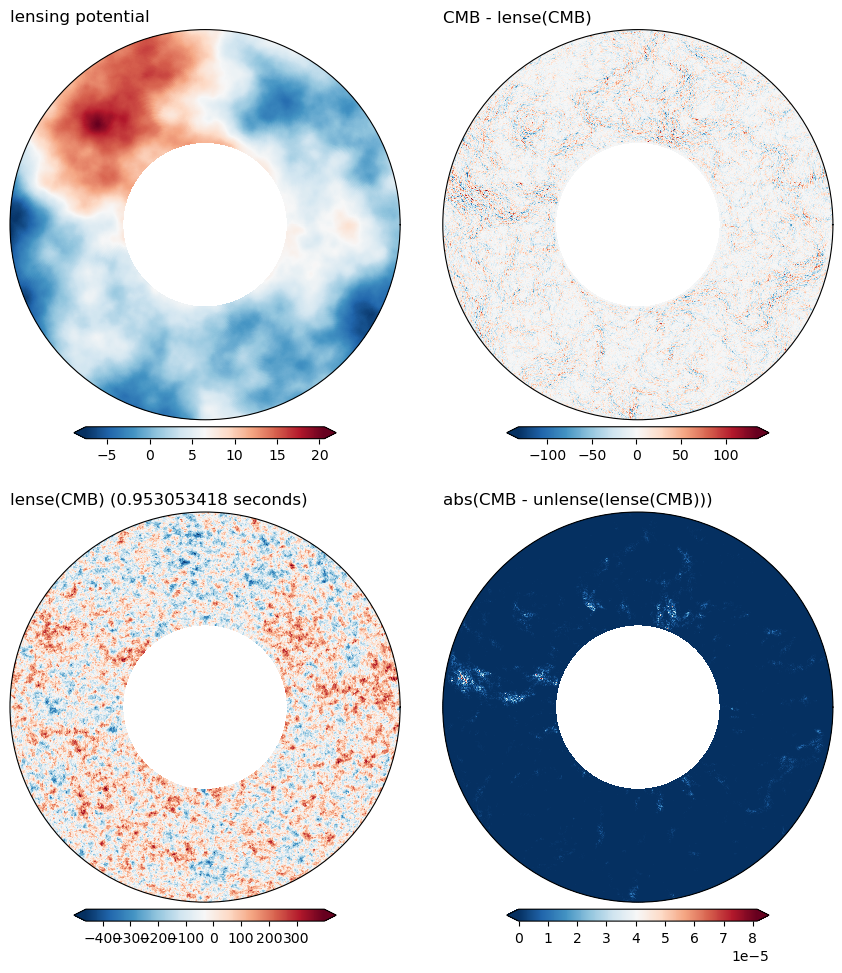

In [23]:
@sblock let Ł, ϕ_az=az_sim(tmU, Φaz), Σaz, φℝ, θℝ, fφ=1/2, hide_plots
    hide_plots && return

    Ln = Ł(ϕ_az)
    t_az   = Xmap(az_sim(fieldtransform(ϕ_az), Σaz))
    lnt_az = Ln * t_az
    lense_time = @belapsed $Ln * $t_az
    t_az′      = Ln \ lnt_az

    imgs = Dict(
        1 => ϕ_az[:],
        2 => lnt_az[:],
        3 => (t_az - lnt_az)[:],
        4 => abs.(t_az[:] .- t_az′[:]),
    )
    txt =  Dict(
        1 => "lensing potential",
        2 => "lense(CMB) ($(lense_time) seconds)",
        3 => "CMB - lense(CMB)",
        4 => "abs(CMB - unlense(lense(CMB)))",
    )
    ctxt = Dict(
        4 => "w"
    )
    # brickplot(imgs; txt=txt, ctxt=ctxt, fφ=fφ)
    diskplot(imgs, φℝ', π.-θℝ; txt=txt, nrows=2, fontsize=12)
end;

Simulate data
================================================

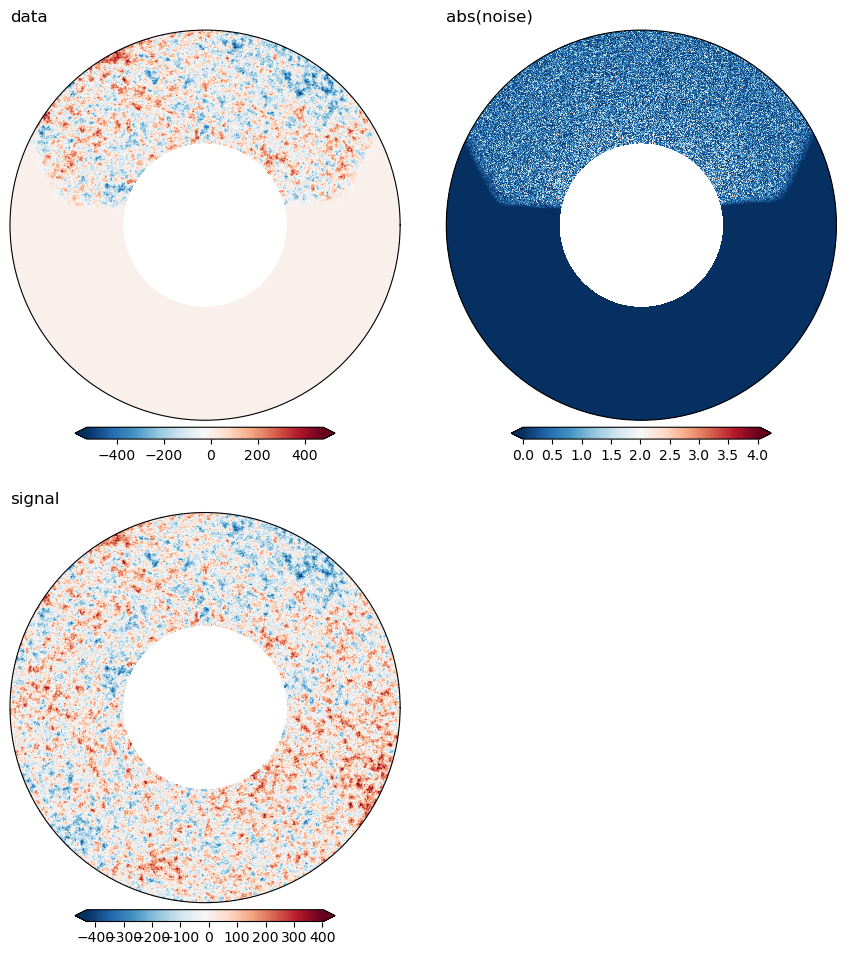

In [24]:
ϕ_az  = az_sim(tmU, Φaz) |> Xfourier
t_az  = az_sim(tmU, Σaz) |> Xfourier
d_az  = Pr * (Baz * (Ł(ϕ_az)*t_az) + az_sim(tmU, Naz)) |> Xfourier;


@sblock let Ł, Baz, t_az, d_az, ϕ_az, θℝ, φℝ, Pr, hide_plots
    hide_plots && return
    imgs = Dict(
        1 => d_az[:],
        2 => t_az[:],
        3 => abs.((d_az - Pr * (Baz * (Ł(ϕ_az)*t_az)))[:])
    )
    txt =  Dict(
        1 => "data",
        2 => "signal",
        3 => "abs(noise)"
    )
    ctxt = Dict(
        3 => "w"
    )
    # brickplot(imgs; txt=txt, ctxt=ctxt, fφ=1)
    diskplot(imgs, φℝ', π.-θℝ; txt=txt, nrows=2, fontsize=12)
end;

Put settings and needed parameters in ds ...
===========================================

In [25]:
ds = (;
    tmU, Ł, ∇!, ϕ2v, ϕ2vᴴ, Pr, Qr,
    Σaz_fctr=Σaz, Φaz_fctr=Φaz, Naz_fctr=Naz, Baz,
    Precon_fctr, NΦNaz,
    grad_nsteps = 14, pcg_nsteps=125,
    linesearch_time_max = 60*3,
);

(tmU = 𝕎{Float64,2,Float64,Float64}((283, 3071), (false, true), 0.01804513318462704, (283.0, 6.283185307179586)), Ł = var"#44#49"{Int64,Nabla!{SparseMatrixCSC{Float32,Int64},SparseMatrixCSC{Float32,Int64}},var"#42#47"{Float64,SparseMatrixCSC{Float32,Int64},SparseMatrixCSC{Float32,Int64},Array{Float32,1}}}(14, Nabla!{SparseMatrixCSC{Float32,Int64},SparseMatrixCSC{Float32,Int64}}(
  [2  ,   1]  =  -407.437
  [283,   1]  =  407.437
  [1  ,   2]  =  407.437
  [3  ,   2]  =  -407.437
  [2  ,   3]  =  407.437
  [4  ,   3]  =  -407.437
  [3  ,   4]  =  407.437
  [5  ,   4]  =  -407.437
  [4  ,   5]  =  407.437
  [6  ,   5]  =  -407.437
  [5  ,   6]  =  407.437
  [7  ,   6]  =  -407.437
  ⋮
  [278, 277]  =  -407.437
  [277, 278]  =  407.437
  [279, 278]  =  -407.437
  [278, 279]  =  407.437
  [280, 279]  =  -407.437
  [279, 280]  =  407.437
  [281, 280]  =  -407.437
  [280, 281]  =  407.437
  [282, 281]  =  -407.437
  [281, 282]  =  407.437
  [283, 282]  =  -407.437
  [1  , 283]  =  -407.437
 

In [26]:
function ll′lnf(ϕ, lnf, Ł, Σaz_fctr)
    f  =  Ł(ϕ) \ lnf
    wk = f[!]
    for (Σ, wkc) ∈ zip(Σaz_fctr, eachcol(wk))
        ldiv!(Σ.L, wkc)
    end
    wx = Xfourier(fieldtransform(f), wk)[:]
    rtn  = - dot(wx,wx) / 2
    rtn
end


function ll′ϕfield(ϕ, data, Φaz_fctr)
    wk = deepcopy(ϕ[!])
    for (Σ, wkc) ∈ zip(Φaz_fctr, eachcol(wk))
        ldiv!(Σ.L, wkc)
    end
    Xfourier(fieldtransform(ϕ), wk)
end

function ll′ϕ(ϕ, data, Φaz_fctr)
	w = ll′ϕfield(ϕ, data, Φaz_fctr)
    wx = w[:]
    - dot(wx,wx) / 2
end


function ∇ϕ′(ϕ, lnf, data; Pr, Σaz_fctr, Naz_fctr, Baz, ϕ2v, ϕ2vᴴ, Ł, ∇!, tmU, grad_nsteps, ds...)

    # Remark: for this to be correct Naz_fctr must be diagonal in pixel space
    dΔlnf     = Baz' * (Pr' * (Naz_fctr \ (data - Pr * (Baz * lnf))))
    v         = ϕ2v(ϕ)
    f         = Ł(ϕ) \ lnf
    τŁ₀₁      = CMBrings.FieldLensing.τArrayLense(v, (f[:],), ∇!, 0, 1, grad_nsteps)
    τŁ₁₀      = CMBrings.FieldLensing.τArrayLense(v, (lnf[:],), ∇!, 1, 0, grad_nsteps)
    τv₀, τf   = τŁ₁₀(map(zero,v),  (dΔlnf[:],))
    ∇f        = Xmap(tmU, τf[1]) - Σaz_fctr \ f
    τv₁, τlnf = τŁ₀₁(τv₀,  (∇f[:],))
    # return ϕ2vᴴ(τv₁) - Φaz⁻¹_fctr * ϕ
    # testing!!!
    return ϕ2vᴴ(τv₁)
end

function update_ϕ′(ϕ, lnf, data; Pr, NΦNaz, Σaz_fctr, Naz_fctr, Φaz_fctr, Baz, ϕ2v, ϕ2vᴴ, Ł, ∇!, tmU, grad_nsteps, linesearch_time_max,  ds...)

    gradϕ = ∇ϕ′(ϕ, lnf, data; Pr, Σaz_fctr, Naz_fctr, Baz, ϕ2v, ϕ2vᴴ, Ł, ∇!, tmU, grad_nsteps)
    inHgrad = NΦNaz * ((Φaz_fctr * gradϕ) - ϕ)
    # Note that ∇ϕ′ skips the Φ⁻¹⋅ϕ term ... so it is added to inHgrad.
    # With the approx inverse Hessian of the form (Φ⁻¹ + N⁻¹)⁻¹ = N(Φ + N)⁻¹Φ
    # we get to cancel it out so that (Φ⁻¹ + N⁻¹)⁻¹⋅Φ⁻¹⋅ϕ == N(Φ + N)⁻¹⋅ϕ

    # solver = :LN_SBPLX
    solver = :LN_COBYLA
    # solver = :LN_NELDERMEAD
    T   = eltype_in(tmU)
    opt = NLopt.Opt(solver, 1)
    opt.maxtime      = linesearch_time_max
    opt.upper_bounds = T[1.0]
    opt.lower_bounds = T[0]
    # opt.initial_step = T[0.00001]
    opt.max_objective = function (β, grad)
        ϕβ = ϕ + β[1] * inHgrad
        ll′lnf(ϕβ, lnf, Ł, Σaz_fctr) + ll′ϕ(ϕβ, data, Φaz_fctr)
    end

    ll_opt, β_opt, = NLopt.optimize(opt,  T[0])
    @show ll_opt, β_opt

    return ϕ + β_opt[1] * inHgrad
end

update_ϕ′ (generic function with 1 method)

newton/gibbs iterations
================================================

In [27]:
# initalize ϕ_cr, t_cr, lnt_cr
ϕ_cr   = Xfourier(tmU)
lnt_cr = Xfourier(tmU)

Xfourier{𝕎{Float64,2,Float64,Float64},Float64,Complex{Float64},2}(𝕎{Float64,2,Float64,Float64}((283, 3071), (false, true), 0.01804513318462704, (283.0, 6.283185307179586)), Complex{Float64}[0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im])

iterate ...

In [28]:
for itr = 1:10
    global ϕ_cr, lnt_cr, t_cr, hst
    @time lnt_cr, t_cr, hst = CMBrings.update_lnf_f(ϕ_cr, d_az; ds...)
    @time ϕ_cr              = update_ϕ′(ϕ_cr, lnt_cr, d_az; ds...)
end
# ll′ϕfield(ϕ_cr, d_az, ds.Φaz_fctr)[!] .|> abs .|> log |> matshow
# ll′ϕfield(ϕ_az, d_az, ds.Φaz_fctr)[!] .|> abs .|> log |> matshow



# gradϕ = ∇ϕ′(ϕ_cr, lnt_cr, d_az; ds...)
# inHgrad = NΦNaz * (Φaz * gradϕ - ϕ_cr)
# ϕβ = ϕ_cr + 0.01 * inHgrad
# ll′ϕfield(ϕβ, d_az, ds.Φaz_fctr)[!] .|> abs .|> log |> matshow
# ll′lnf(ϕβ, lnt_cr,  ds.Ł, ds.Σaz_fctr)
# ll′ϕ(ϕβ, d_az, ds.Φaz_fctr)

# ϕβ[:] |> matshow
# ϕ_az[:] |> matshow
# (ds.Ł(ϕβ) \ lnt_cr)[:] |> matshow



# βs = vcat(0, rand(Tp, 19) ./ 1) |> sort
# lls1 = zeros(Tp, 20)
# lls2 = zeros(Tp, 20)
# for i=1:20
# 	ϕβ = ϕ_cr + βs[i] * inHgrad
#  ## ϕβ.fd[:,1] .= 0
# 	lls1[i] = ll′lnf(ϕβ, lnt_cr,  ds.Ł, ds.Σaz_fctr)
# 	lls2[i] = ll′ϕ(ϕβ, d_az, ds.Φaz_fctr)
# end
# #plot(βs, lls1)
# #plot(βs, lls2)
# # plot(βs, lls1 .+ lls2)
# hcat(βs, lls1, lls2, lls1 .+ lls2 ./ 100)

421.997189 seconds (3.85 M allocations: 85.845 GiB, 10.69% gc time)
(ll_opt, β_opt) = (-425868.75154582644, [0.707465648694779])
195.940363 seconds (5.85 M allocations: 34.423 GiB, 10.02% gc time)
417.674238 seconds (377.99 k allocations: 85.663 GiB, 11.05% gc time)
(ll_opt, β_opt) = (-429366.20292400004, [0.6100793480873109])
193.080182 seconds (485.70 k allocations: 33.817 GiB, 6.21% gc time)
412.894578 seconds (303.33 k allocations: 85.659 GiB, 10.91% gc time)
(ll_opt, β_opt) = (-433401.18585065135, [0.3766617774958838])
191.924282 seconds (94.40 k allocations: 34.011 GiB, 6.07% gc time)
412.133844 seconds (303.28 k allocations: 85.659 GiB, 10.89% gc time)
(ll_opt, β_opt) = (-432944.7368143058, [0.3029094897210598])
191.493761 seconds (94.44 k allocations: 34.011 GiB, 6.11% gc time)
413.362709 seconds (303.34 k allocations: 85.659 GiB, 10.86% gc time)
(ll_opt, β_opt) = (-430936.6803140515, [0.36736028828454437])
191.954216 seconds (94.41 k allocations: 34.011 GiB, 6.12% gc time)
412

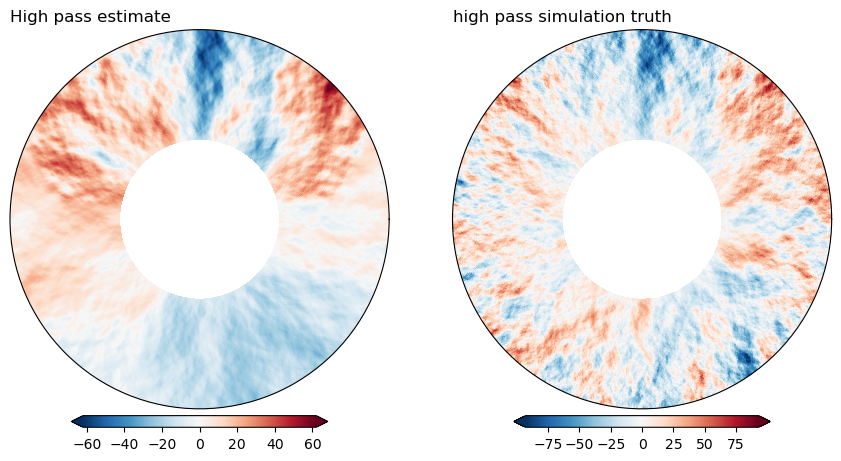

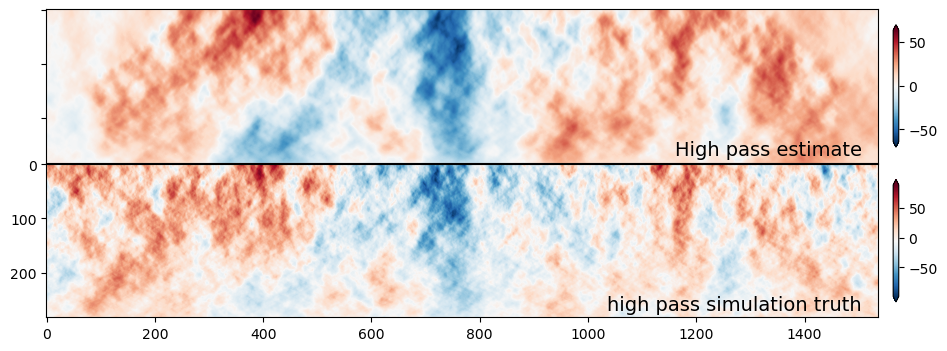

(Figure(PyObject <Figure size 1085.51x350 with 4 Axes>), PyCall.PyObject[PyObject <matplotlib.axes._subplots.AxesSubplot object at 0x7fd048bccf50>, PyObject <matplotlib.axes._subplots.AxesSubplot object at 0x7fd091dc9dd0>])

In [32]:
# @sblock let fest = nH⁻¹∇ϕ, ftru = ϕ_az, tmU, φℝ, θℝ, Pr
@sblock let fest = ϕ_cr, ftru = ϕ_az, tmU, φℝ, θℝ, Pr
    k   = CMBrings.fullfreq(tmU)

    # ----------------------
    fltr = abs.(k[2])
    # fltr = ones(eltype_out(tmU), size_out(tmU))
    # fltr[:,1:10] .= 0
    ##---------------------
    beamfwhm = (arcmin=30.0; deg2rad(arcmin/60))
    σ² = beamfwhm^2 / 8 / log(2)
    bmk = exp.( .- σ² .* k[2].^2 ./ 2)
    ##------------------------
    𝔹 = I
    # 𝔹 = Xfourier(tmU,bmk) |> DiagOp
    𝔽 = Xfourier(tmU,fltr) |> DiagOp
    ##𝔽 = I
    # 𝕄 = Pr
    𝕄 = I

    diskplot(
        # Dict(1=> sin²θℝ .* (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        Dict(1=> (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        φℝ', π.-θℝ;
        txt=Dict(1=>"High pass estimate", 2=>"high pass simulation truth"),
        nrows=1, fontsize=12, vcenter=0, vmin_quantile=1e-4,
    )

    brickplot(
        Dict(1=> (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        txt=Dict(1=>"High pass estimate", 2=>"high pass simulation truth"),
        fφ=1/2
    )

end

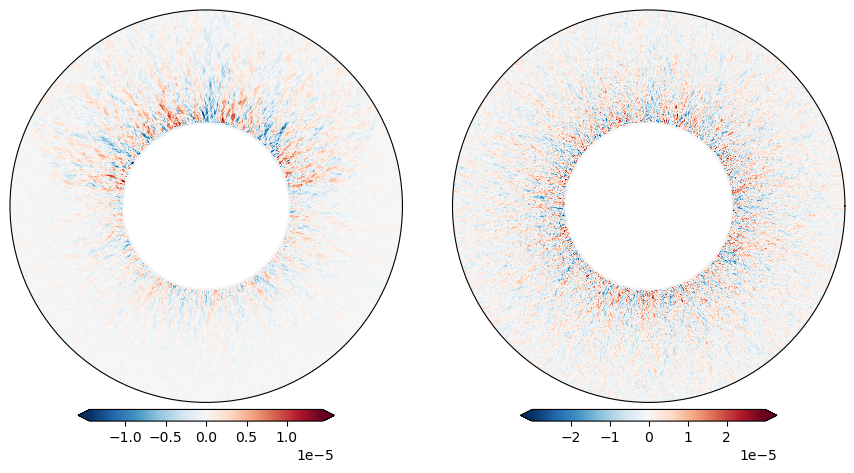

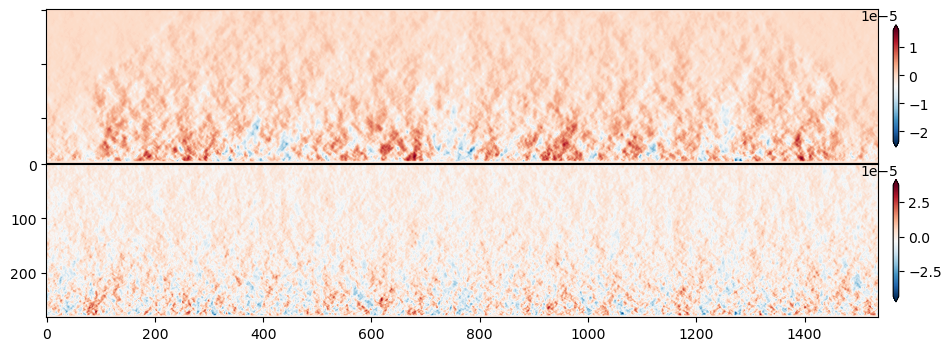

(Figure(PyObject <Figure size 1085.51x350 with 4 Axes>), PyCall.PyObject[PyObject <matplotlib.axes._subplots.AxesSubplot object at 0x7fd07207d390>, PyObject <matplotlib.axes._subplots.AxesSubplot object at 0x7fd1f20bc3d0>])

In [30]:
@sblock let fest = ϕ2vᴴ(ϕ2v(ϕ_cr )), ftru = ϕ2vᴴ(ϕ2v(ϕ_az)), φℝ, θℝ, Pr, tmU

    k   = CMBrings.fullfreq(tmU)

    ##---------------------
    beamfwhm = (arcmin=10.0; deg2rad(arcmin/60))
    σ² = beamfwhm^2 / 8 / log(2)
    bmk = exp.( .- σ² .* k[2].^2 ./ 2)
    ##------------------------
    𝔹 = I
    ##𝔹 = Xfourier(tmU,bmk) |> DiagOp
    ##𝕄 = Pr
    𝕄 = I


    diskplot(
        Dict(1=> (𝕄 * fest)[:], 2 =>(𝕄 * 𝔹 * ftru)[:]),
        φℝ', π.-θℝ; nrows=1, fontsize=14, vcenter=0, vmin_quantile=1e-4,
    )

    brickplot(
        Dict(1=> (𝕄 * fest)[:], 2 =>(𝕄 * 𝔹 * ftru)[:]),
        fφ=1/2
    )

end

In [31]:
ln_az    = length(d_az[:])
zll_t_az = (dot(t_az[:], (Σaz \ t_az)[:]) - ln_az) / sqrt(2*ln_az) # PCG sim
zll_t_cr = (dot(t_cr[:], (Σaz \ t_cr)[:]) - ln_az) / sqrt(2*ln_az) # PCG sim
@show (zll_t_az, zll_t_cr)

(zll_t_az, zll_t_cr) = (-0.7998715918072055, -3.035734362954188)


(-0.7998715918072055, -3.035734362954188)

More newton/gibbs iterations
================================================

In [ ]:
# initalize ϕ_cr, t_cr, lnt_cr
ϕ_cr   = Xfourier(tmU)
lnt_cr = Xfourier(tmU)

iterate ...

In [ ]:
for itr = 1:40
    global ϕ_cr, lnt_cr, t_cr, hst
    @time lnt_cr, t_cr, hst = CMBrings.update_lnf_f(ϕ_cr, d_az; ds...)
    @time ϕ_cr              = update_ϕ′(ϕ_cr, lnt_cr, d_az; ds...)
end

In [ ]:
# @sblock let fest = nH⁻¹∇ϕ, ftru = ϕ_az, tmU, φℝ, θℝ, Pr
@sblock let fest = ϕ_cr, ftru = ϕ_az, tmU, φℝ, θℝ, Pr
    k   = CMBrings.fullfreq(tmU)

    # ----------------------
    fltr = abs.(k[2])
    # fltr = ones(eltype_out(tmU), size_out(tmU))
    fltr[:,1:10] .= 0
    ##---------------------
    beamfwhm = (arcmin=30.0; deg2rad(arcmin/60))
    σ² = beamfwhm^2 / 8 / log(2)
    bmk = exp.( .- σ² .* k[2].^2 ./ 2)
    ##------------------------
    𝔹 = I
    # 𝔹 = Xfourier(tmU,bmk) |> DiagOp
    𝔽 = Xfourier(tmU,fltr) |> DiagOp
    ##𝔽 = I
    # 𝕄 = Pr
    𝕄 = I

    diskplot(
        # Dict(1=> sin²θℝ .* (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        Dict(1=> (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        φℝ', π.-θℝ;
        txt=Dict(1=>"High pass estimate", 2=>"high pass simulation truth"),
        nrows=1, fontsize=12, vcenter=0, vmin_quantile=1e-4,
    )

    brickplot(
        Dict(1=> (𝕄 * 𝔽 * fest)[:], 2 =>(𝕄 * 𝔹 * 𝔽 * ftru)[:]),
        txt=Dict(1=>"High pass estimate", 2=>"high pass simulation truth"),
        fφ=1/2
    )

end

In [ ]:
@sblock let fest = ϕ2vᴴ(ϕ2v(ϕ_cr )), ftru = ϕ2vᴴ(ϕ2v(ϕ_az)), φℝ, θℝ, Pr, tmU

    k   = CMBrings.fullfreq(tmU)

    ##---------------------
    beamfwhm = (arcmin=10.0; deg2rad(arcmin/60))
    σ² = beamfwhm^2 / 8 / log(2)
    bmk = exp.( .- σ² .* k[2].^2 ./ 2)
    ##------------------------
    𝔹 = I
    ##𝔹 = Xfourier(tmU,bmk) |> DiagOp
    ##𝕄 = Pr
    𝕄 = I


    diskplot(
        Dict(1=> (𝕄 * fest)[:], 2 =>(𝕄 * 𝔹 * ftru)[:]),
        φℝ', π.-θℝ; nrows=1, fontsize=14, vcenter=0, vmin_quantile=1e-4,
    )

    brickplot(
        Dict(1=> (𝕄 * fest)[:], 2 =>(𝕄 * 𝔹 * ftru)[:]),
        fφ=1/2
    )

end

In [ ]:
ln_az    = length(d_az[:])
zll_t_az = (dot(t_az[:], (Σaz \ t_az)[:]) - ln_az) / sqrt(2*ln_az) # PCG sim
zll_t_cr = (dot(t_cr[:], (Σaz \ t_cr)[:]) - ln_az) / sqrt(2*ln_az) # PCG sim
@show (zll_t_az, zll_t_cr)